<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Temporal_Discourse_Analysis_of_News_Headlines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temporal Discourse Analysis of News Headlines

This practice explores temporal discourse patterns in a large news headline corpus using keyword frequency and TF-IDF analysis. By aggregating headlines by year, the analysis examines how certain keywords become dominant, persistent, or highly concentrated during specific periods.

Rather than focusing on document classification, this practice investigates how news language changes over time and how major social, political, and global events appear through temporal keyword trends.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("therohk/million-headlines")

print("Path to dataset files:", path)

100%|██████████| 21.4M/21.4M [00:00<00:00, 77.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/therohk/million-headlines/versions/5


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
df = pd.read_csv(os.path.join(path, 'abcnews-date-text.csv'))
df.head()

,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers


In [4]:
df["year"] = df["publish_date"].astype(str).str[:4]

In [5]:
df.head()

,publish_date,headline_text,year
0,20030219,aba decides against community broadcasting lic...,2003
1,20030219,act fire witnesses must be aware of defamation,2003
2,20030219,a g calls for infrastructure protection summit,2003
3,20030219,air nz staff in aust strike for pay rise,2003
4,20030219,air nz strike to affect australian travellers,2003


In [6]:
year_texts = (
    df.groupby("year")["headline_text"].apply(lambda x: " ".join(x))
)

# ■ CountVectorizer

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

In [42]:
vectorizer = CountVectorizer(
    stop_words = "english",
    min_df = 2
)

In [43]:
X = vectorizer.fit_transform(year_texts)

In [66]:
word_df = pd.DataFrame(
    X.toarray(),
    index = year_texts.index,
    columns = vectorizer.get_feature_names_out()
)

word_df

,00,000,007,01,0101,0105,0106,0107,0108,0109,...,zuri,zurich,zusak,zussino,zverev,zvi,zvonareva,zwaanswijk,zwartz,zyl
year,,,,,,,,,,,,,,,,,,,,,
2003,0,10,0,0,0,0,0,0,0,0,...,0,9,0,0,0,0,4,0,0,1
2004,0,4,0,0,0,0,0,0,0,0,...,0,10,0,0,0,0,3,0,0,0
2005,0,9,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,1,0,0,0
2006,1,5,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,3,0,0,1
2007,0,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008,0,2,1,1,0,0,0,0,0,0,...,0,2,0,0,0,0,8,0,0,0
2009,1,12,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,4,0,0,0
2010,0,4,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,4,0,0,0
2011,0,3,0,1,0,0,0,0,0,0,...,0,2,0,0,0,0,14,2,0,0


In [56]:
word_df.loc["2021"].sort_values(ascending=False).head(20)

,2021
covid,1883
new,910
19,910
nsw,795
australia,764
says,718
vaccine,694
coronavirus,562
cases,534
police,467


In [51]:
word_df["trump"]

,trump
year,
2003,1
2004,3
2005,4
2006,4
2007,2
2008,2
2009,3
2010,6
2011,10


In [34]:
import matplotlib.pyplot as plt

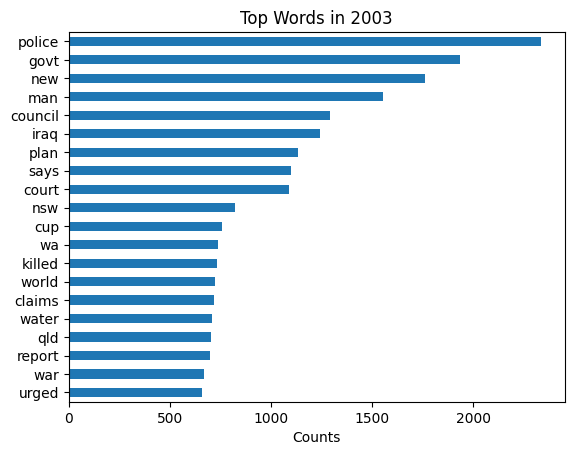

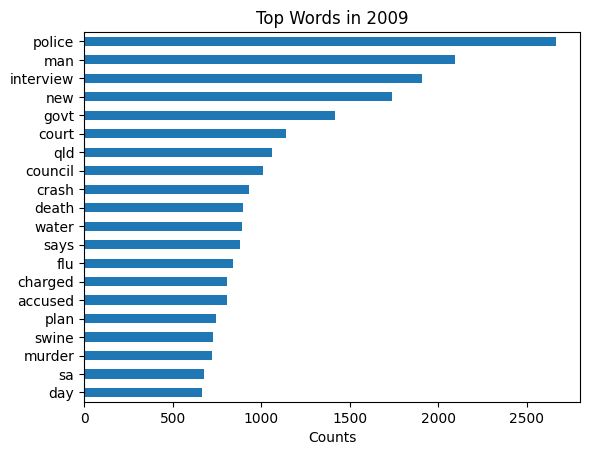

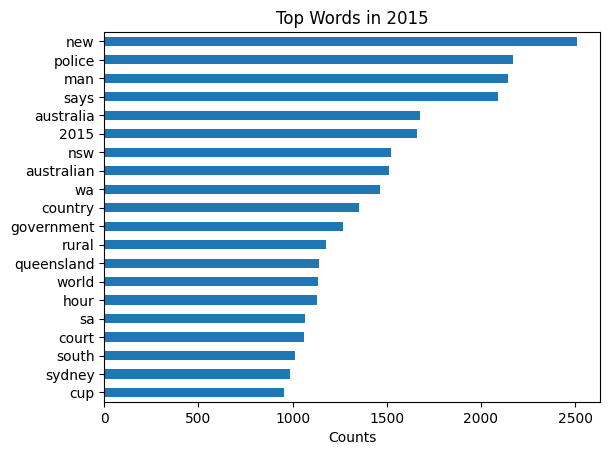

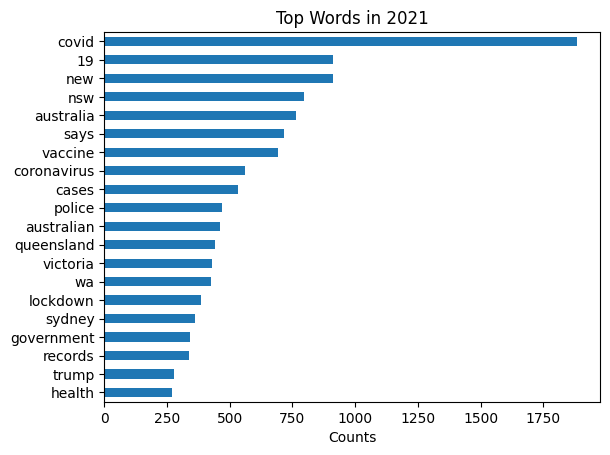

In [95]:
years = ["2003", "2009", "2015", "2021"]

for year in years:

    top_words = word_df.loc[year].sort_values(ascending=False).head(20)
    top_words.sort_values().plot(kind="barh")
    plt.title(f"Top Words in {year}")
    plt.xlabel("Counts")
    plt.show()

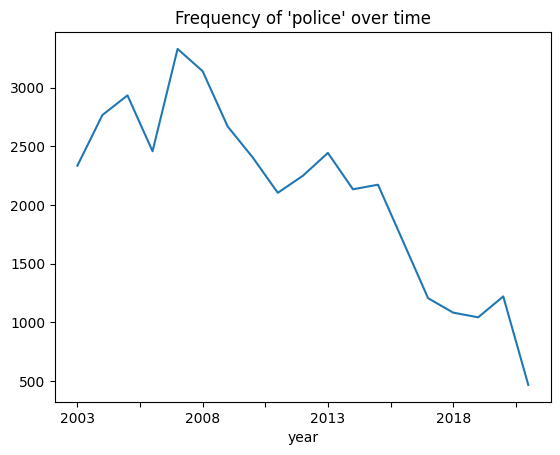

In [101]:
word_df["police"].plot()
plt.title("Frequency of 'police' over time")
plt.show()

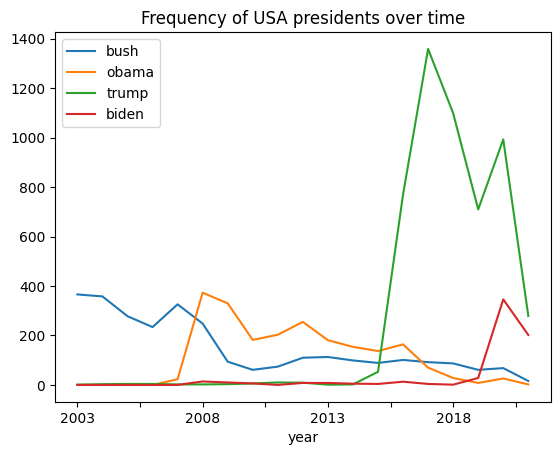

In [98]:
word_president = ["bush", "obama", "trump", "biden"]
word_df[word_president].plot()
plt.title(f"Frequency of USA presidents over time")
plt.show()

# ■ TF-IDF

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [64]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words = "english",
    min_df = 2,
    max_features = 5000
)

X_tfidf = tfidf_vectorizer.fit_transform(year_texts)

In [67]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    index = year_texts.index,
    columns = tfidf_vectorizer.get_feature_names_out()
)

tfidf_df

,10,100,1000,100m,10m,11,12,13,14,15,...,young,youth,youths,youtube,zealand,zero,zimbabwe,zone,zones,zoo
year,,,,,,,,,,,,,,,,,,,,,
2003,0.014395,0.007259,0.002092,0.002338,0.002215,0.009843,0.011196,0.004552,0.005414,0.005906,...,0.012304,0.021040,0.001599,0.000000,0.008490,0.001230,0.021989,0.007751,0.001969,0.004306
2004,0.011576,0.006505,0.001433,0.003197,0.002205,0.009371,0.010584,0.004189,0.007166,0.005182,...,0.012568,0.018962,0.002977,0.000000,0.006284,0.001323,0.024108,0.005512,0.002977,0.002977
2005,0.010971,0.004367,0.001917,0.002343,0.003515,0.005432,0.009160,0.003941,0.003728,0.004367,...,0.012995,0.014805,0.003728,0.000000,0.005113,0.000533,0.014781,0.006284,0.001385,0.003408
2006,0.010865,0.006495,0.003070,0.003543,0.002008,0.005787,0.005669,0.003543,0.006377,0.004015,...,0.017124,0.017124,0.002008,0.000412,0.003070,0.000945,0.002731,0.005669,0.002716,0.003070
2007,0.010111,0.005551,0.001685,0.003668,0.002280,0.005650,0.006245,0.004262,0.005650,0.006245,...,0.015563,0.017942,0.002875,0.004033,0.003965,0.001685,0.008232,0.005353,0.002577,0.003866
2008,0.014621,0.006748,0.002556,0.006646,0.003067,0.008589,0.007464,0.004806,0.007259,0.008589,...,0.014928,0.020347,0.003067,0.002734,0.004294,0.001738,0.032999,0.004601,0.001534,0.005726
2009,0.013034,0.010087,0.001700,0.002380,0.003060,0.005893,0.008500,0.004420,0.007027,0.008047,...,0.018020,0.020514,0.001700,0.003426,0.002720,0.002267,0.006315,0.007253,0.001473,0.005213
2010,0.012965,0.005540,0.001768,0.002004,0.002004,0.005068,0.006600,0.004597,0.005068,0.006129,...,0.021923,0.017680,0.001886,0.001507,0.003182,0.002239,0.001983,0.006365,0.003890,0.004125
2011,0.012284,0.005716,0.002554,0.001460,0.001703,0.011311,0.007054,0.004014,0.004500,0.005716,...,0.023474,0.018852,0.001581,0.001414,0.007054,0.001946,0.003836,0.012771,0.004379,0.005352


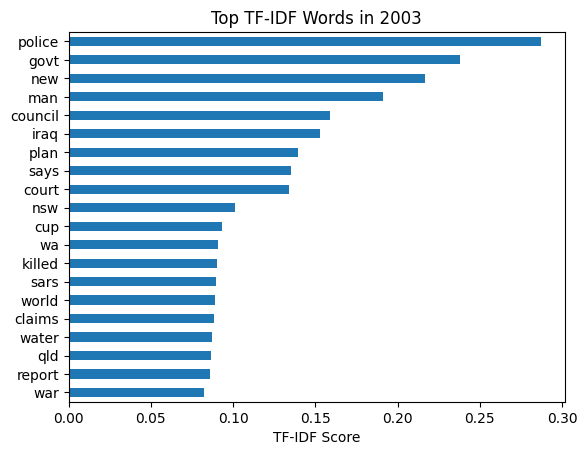

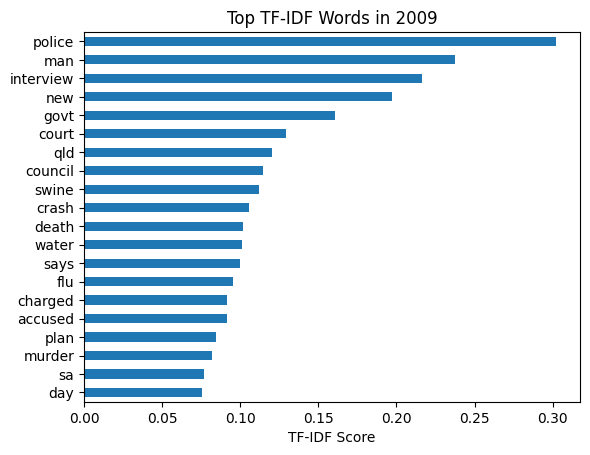

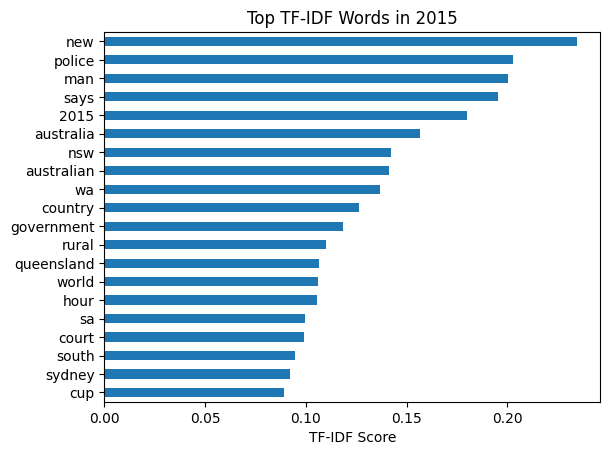

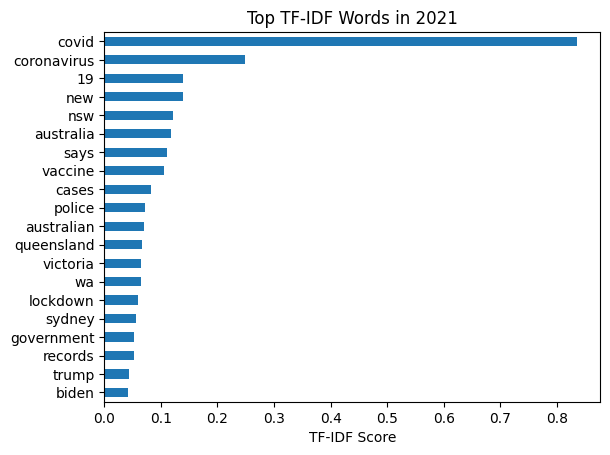

In [96]:
years = ["2003", "2009", "2015", "2021"]

for year in years:

    top_words_tfidf = tfidf_df.loc[year].sort_values(ascending=False).head(20)
    top_words_tfidf.sort_values().plot(kind="barh")
    plt.title(f"Top TF-IDF Words in {year}")
    plt.xlabel("TF-IDF Score")
    plt.show()

In [68]:
tfidf_df.loc["2020"].sort_values(ascending=False).head(20)

,2020
coronavirus,0.916229
covid,0.296520
australia,0.069491
19,0.068925
nsw,0.061719
covid19,0.058364
new,0.057041
victoria,0.050515
queensland,0.050213
police,0.046063


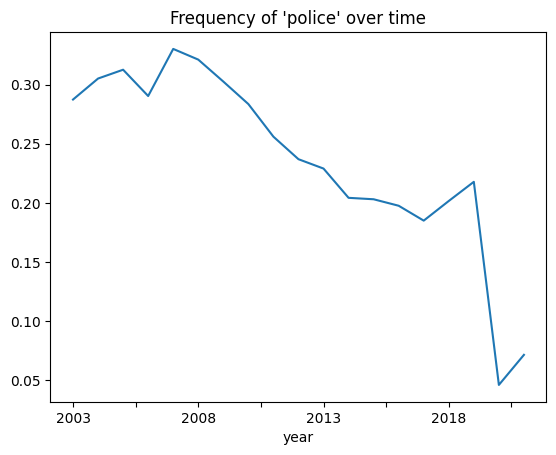

In [103]:
tfidf_df["police"].plot()
plt.title("Frequency of 'police' over time")
plt.show()

In [104]:
word_df["police"].sort_values(ascending=False)

,police
year,
2007,3330
2008,3140
2005,2934
2004,2767
2009,2669
2006,2458
2013,2444
2010,2405
2003,2335


※ 'police'는 점차 줄어드는 추세이지만 초반에 자주 등장 > 후에 줄어듦
- year_texts 기준으로 분석하였으므로 데이터가 2003~2021의 19개, 그 중 초반에 크게 많이 등장하였으므로 TF-IDF 높은 것으로 추정됨

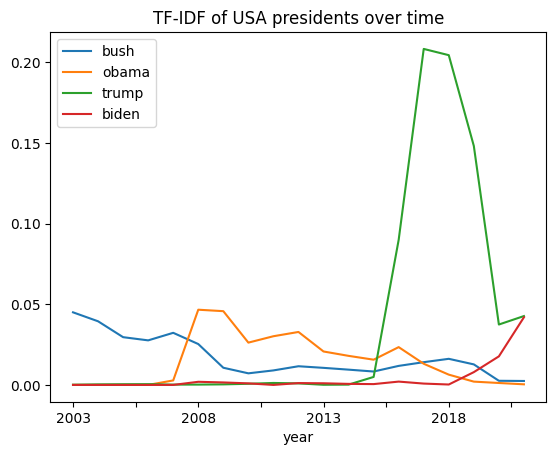

In [100]:
tfidf_df[word_president].plot()
plt.title(f"TF-IDF of USA presidents over time")
plt.show()

※ Count에서도 trump가 급격히 상승하였던 모습이 확인되었지만 TF-IDF는 더 가파르게 올라감
- 타 대통령들 이름은 상대적으로 평탄해짐
- 타 시기에 비해 급작스럽게, 급격하게 많이 언급되었기 때문으로 추정

#■ Conclusion

The analysis revealed clear temporal differences in news discourse across years. Some keywords appeared as short-term spikes connected to major events, while others remained persistent across long periods as structural components of news coverage.

TF-IDF analysis was particularly useful for identifying words that were strongly associated with specific time periods rather than simply being frequent overall. The results show that temporal keyword analysis can provide an interpretable way to explore discourse change in large headline corpora.